# Tournament eval (Maia2 concat) — **2-class** (Weak/Medium/Strong + ALL)

Test-only evaluation of **already trained** MLP checkpoints from the original 6-bin notebook on a **tournament** dataset.

- Input features: Maia2 embeddings combined as `combine(fen_before_emb, fen_after_emb)` (same `combine_mode` as training, default `concat`).
- Labels: `move_label` (`0=human`, `1=cheat`).
- Row filter: `is_used == True`.
- Bins: by `player_elo`  

Outputs: the same metric tables + per-bin `classification_report` + heatmaps.


In [1]:
# === Imports / seeds ===
from __future__ import annotations

import subprocess
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import json
import math
import time

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

from IPython.display import display

# -----------------------------
# Determinism
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# === Spec / knobs (kept close to the training notebook) ===

# Same metrics as in training notebook
METRIC_NAMES = [
    "accuracy",
    "micro_f1",
    "macro_f1",
    "cheat_precision",
    "cheat_recall",
    "cheat_f1",
]

# Elo bins for this tournament eval
BIN_NAMES: List[str] = ["<1.6k", "1.6-1.8k", "1.8-2.0k", "2.0-2.2k", ">2.2k"]

def elo_bin_name(elo: int) -> str:
    if elo < 1600:
        return "<1.6k"
    if elo < 1800:
        return "1.6-1.8k"
    if elo < 2000:
        return "1.8-2.0k"
    if elo < 2200:
        return "2.0-2.2k"
    return ">2.2k"

# Feature combine mode (must match training)
#   - concat:   [e_before, e_after]
#   - rich:     [e_before, e_after, |diff|, prod]
#   - diffprod: [|diff|, prod]
#   - mean:     (e_before + e_after) / 2
COMBINE_MODE = "concat"

# Architecture specs (must contain the run_ids referenced by selected_models.csv)
DEFAULT_FIXED_SPECS: Dict[str, Dict[str, Any]] = {
    # Keep the same IDs as in the training notebook
    "mlp_002": {"hidden_dim": 256,  "act": "GELU", "norm": "batch", "drop": 0.0, "lr": 3e-4, "weight_decay": 3e-4},
}

# Expected label schema
CLASS_LABELS = [0, 1]
CLASS_NAMES = ["human", "cheat"]


In [3]:
# === Paths / output ===

def get_repo_root_git() -> Path:
    p = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
    return Path(p)

REPO_ROOT = get_repo_root_git()
print("REPO_ROOT:", REPO_ROOT)

# ---- Tournament dataset ----
TOURNAMENT_CSV_PATH = REPO_ROOT / "data/interim/tournament/02_pov_tournament.csv"  # TODO
TOURNAMENT_EMB_NPZ_PATH  = REPO_ROOT / "data/processed/tournament" / "04_embs_maia2_2050.npz"  # TODO

# ---- Trained models to evaluate (produced by the training notebook) ----
# Point this to the *training run* output dir that contains:
#   - tables/selected_models.csv
#   - models/<cheat_name>/<run_id>/model.pt
TRAIN_RUN_OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/03_2cls_6bins" / "maia2_2050_concat"  # TODO

SELECTED_MODELS_CSV = TRAIN_RUN_OUT_DIR / "tables/selected_models.csv"

# ---- Outputs ----
OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/04_tournament_eval_2cls" / "maia2_2050_concat"
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "curves").mkdir(parents=True, exist_ok=True)

print("TOURNAMENT_CSV_PATH:", TOURNAMENT_CSV_PATH)
print("TOURNAMENT_EMB_NPZ :", TOURNAMENT_EMB_NPZ_PATH)
print("SELECTED_MODELS_CSV:", SELECTED_MODELS_CSV)
print("OUT_DIR:", OUT_DIR)

# Optional: if your tournament CSV has an explicit NPZ row-id column (e.g., 'Unnamed: 0' or 'npz_row'),
# set it here. If None, the CSV index is used as NPZ row id.
NPZ_ROW_COL: Optional[str] = None

# NPZ embedding keys (override if your NPZ uses different names)
NPZ_EMB_BEFORE_KEY = "fen_before"
NPZ_EMB_AFTER_KEY  = "fen_after"

REPO_ROOT: /home/jovyan/artem/humanlike
TOURNAMENT_CSV_PATH: /home/jovyan/artem/humanlike/data/interim/tournament/02_pov_tournament.csv
TOURNAMENT_EMB_NPZ : /home/jovyan/artem/humanlike/data/processed/tournament/04_embs_maia2_2050.npz
SELECTED_MODELS_CSV: /home/jovyan/artem/humanlike/new_notebooks/new_reports/03_2cls_6bins/maia2_2050_concat/tables/selected_models.csv
OUT_DIR: /home/jovyan/artem/humanlike/new_notebooks/new_reports/04_tournament_eval_2cls/maia2_2050_concat


In [4]:
# === Load tournament CSV + basic sanity checks ===
df = pd.read_csv(TOURNAMENT_CSV_PATH)

REQUIRED = ["is_used", "move_label", "player_elo", "fen_before", "fen_after", "move_uci"]
missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in tournament CSV: {missing}")

# labels
if not set(df["move_label"].unique()).issubset({0, 1}):
    raise ValueError(f"move_label must be in {{0,1}}. Got: {sorted(df['move_label'].unique().tolist())}")

# NPZ row mapping
if NPZ_ROW_COL is None:
    npz_rows_all = df.index.to_numpy(dtype=np.int64)
else:
    if NPZ_ROW_COL not in df.columns:
        raise KeyError(f"NPZ_ROW_COL='{NPZ_ROW_COL}' not found in CSV columns.")
    npz_rows_all = df[NPZ_ROW_COL].to_numpy(dtype=np.int64)

mask_used = df["is_used"].to_numpy(dtype=bool)
if mask_used.ndim != 1:
    raise ValueError("is_used must be a 1D boolean column.")

df_f = df.loc[mask_used].reset_index(drop=True)
npz_rows = npz_rows_all[mask_used]

print("rows total:", len(df), "| used:", len(df_f))
df_f.head(5)


rows total: 77020 | used: 28410


,tournament_id,game_id,game_result,time_control,player,player_color,player_elo,opponent_elo,half_move,move_uci,fen_before,fen_after,move_label,move_thinking_time,player_engine_hints,player_cheat_depth,cheat_engine_line,is_used
0,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,21,f4g5,r2qk2r/pp3p1p/2nbpn2/3p1p2/3P1B2/2P2N2/PP1N1PP...,r2qk2r/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PPP...,1,2.871923,NaN,14,1.0,True
1,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,23,f1e1,r2qk1r1/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PP...,r2qk1r1/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PP...,1,4.115187,NaN,14,2.0,True
2,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,25,f3g5,r2qk3/pp3p1p/2nbpn2/3p1pr1/3P4/2P2N2/PP1N1PPP/...,r2qk3/pp3p1p/2nbpn2/3p1pN1/3P4/2P5/PP1N1PPP/R2...,1,1.923551,NaN,14,1.0,True
3,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,27,g1h2,r2qk3/pp3p1p/2n1pn2/3p1pN1/3P4/2P5/PP1N1PPb/R2...,r2qk3/pp3p1p/2n1pn2/3p1pN1/3P4/2P5/PP1N1PPK/R2...,1,1.509984,NaN,14,1.0,True
4,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,29,h2g1,r2qk3/pp3p1p/2n1p3/3p1pN1/3P2n1/2P5/PP1N1PPK/R...,r2qk3/pp3p1p/2n1p3/3p1pN1/3P2n1/2P5/PP1N1PP1/R...,1,3.232888,NaN,14,1.0,True


In [5]:
# === Load embeddings NPZ + alignment checks ===
npz = np.load(TOURNAMENT_EMB_NPZ_PATH, allow_pickle=True)
print("NPZ keys:", list(npz.files)[:50], "..." if len(npz.files) > 50 else "")

NPZ keys: ['fen_before', 'fen_after', '__fen_cols__'] 


In [6]:
# === Build X, y for tournament rows ===

def combine_batch(e1: np.ndarray, e2: np.ndarray, mode: str) -> np.ndarray:
    '''Vectorized combine for batches.

    e1,e2: (B,D)
    returns: (B, out_dim)
    '''
    if mode == "concat":
        return np.concatenate([e1, e2], axis=1)
    if mode == "rich":
        diff = np.abs(e1 - e2)
        prod = e1 * e2
        return np.concatenate([e1, e2, diff, prod], axis=1)
    if mode == "diffprod":
        diff = np.abs(e1 - e2)
        prod = e1 * e2
        return np.concatenate([diff, prod], axis=1)
    if mode == "mean":
        return 0.5 * (e1 + e2)
    raise ValueError(f"Unknown combine mode: {mode}")

if NPZ_EMB_BEFORE_KEY not in npz.files:
    raise KeyError(f"NPZ_EMB_BEFORE_KEY='{NPZ_EMB_BEFORE_KEY}' not found in NPZ.")
if NPZ_EMB_AFTER_KEY not in npz.files:
    raise KeyError(f"NPZ_EMB_AFTER_KEY='{NPZ_EMB_AFTER_KEY}' not found in NPZ.")

emb_before = np.asarray(npz[NPZ_EMB_BEFORE_KEY])[npz_rows].astype(np.float32, copy=False)
emb_after  = np.asarray(npz[NPZ_EMB_AFTER_KEY])[npz_rows].astype(np.float32, copy=False)

if emb_before.ndim != 2 or emb_after.ndim != 2:
    raise ValueError(f"Embeddings must be 2D arrays. Got before={emb_before.shape}, after={emb_after.shape}")
if emb_before.shape != emb_after.shape:
    raise ValueError(f"Embeddings shape mismatch: before={emb_before.shape}, after={emb_after.shape}")

X_all = combine_batch(emb_before, emb_after, mode=str(COMBINE_MODE)).astype(np.float32, copy=False)
y_all = df_f["move_label"].to_numpy(dtype=np.int64)

print("emb_before:", emb_before.shape, emb_before.dtype)
print("X_all:", X_all.shape, X_all.dtype)
print("y_all:", y_all.shape, y_all.dtype, "| pos_rate:", float(y_all.mean()))


emb_before: (28410, 1024) float32
X_all: (28410, 2048) float32
y_all: (28410,) int64 | pos_rate: 0.2877507919746568


In [7]:
# === Elo bins (Weak/Medium/Strong + ALL) ===
elo = df_f["player_elo"].to_numpy(dtype=np.int64)
bin_name = np.array([elo_bin_name(int(e)) for e in elo], dtype=object)

# stable order -> idx
BIN_NAME_TO_IDX = {b: i for i, b in enumerate(BIN_NAMES)}
bin_idx = np.array([BIN_NAME_TO_IDX[str(b)] for b in bin_name], dtype=np.int64)

print("bin counts:", pd.Series(bin_name).value_counts().to_dict())


bin counts: {'>2.2k': 8316, '1.8-2.0k': 6348, '2.0-2.2k': 5794, '1.6-1.8k': 4815, '<1.6k': 3137}


In [8]:
# === Model + eval helpers (copied from training notebook) ===

def build_mlp(
    input_dim: int,
    out_dim: int,
    *,
    hidden_dim: int,
    act: str,
    norm: str | None,
    drop: float,
) -> nn.Module:
    layers: List[nn.Module] = [nn.Linear(input_dim, hidden_dim)]

    if norm == "layer":
        layers.append(nn.LayerNorm(hidden_dim))
    elif norm == "batch":
        layers.append(nn.BatchNorm1d(hidden_dim))
    elif norm is None:
        pass
    else:
        raise ValueError(f"Unknown norm: {norm}")

    if act == "ReLU":
        layers.append(nn.ReLU())
    elif act == "GELU":
        layers.append(nn.GELU())
    elif act == "LeakyReLU":
        layers.append(nn.LeakyReLU(0.1))
    else:
        raise ValueError(f"Unknown activation: {act}")

    if drop > 0:
        layers.append(nn.Dropout(drop))

    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)

@torch.no_grad()
def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    """p(cheat=1) for binary model that outputs a single logit per sample."""
    model.eval()
    logits = model(X)                # (N,)
    logits = logits.view(-1)         # (N,)
    p = torch.sigmoid(logits)
    return p.detach().cpu().numpy()  # (N,)

def apply_threshold(p_pos: np.ndarray, thr: float):
    return (p_pos >= float(thr)).astype(np.int64)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "cheat_precision": float(precision_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0)),
        "cheat_recall": float(recall_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0)),
        "cheat_f1": float(f1_score(y_true, y_pred, average="binary", pos_label=1)),
    }

@torch.no_grad()
def eval_one_with_pred(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,
    y: np.ndarray,
) -> tuple[dict[str, float], np.ndarray]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    # Build model (input_dim inferred from X)
    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))

    metrics = compute_metrics(y, y_pred)
    return metrics, y_pred

def _resolve_model_path(p: Path) -> Path:
    if p.is_absolute():
        return p
    # allow paths relative to TRAIN_RUN_OUT_DIR
    cand = TRAIN_RUN_OUT_DIR / p
    if cand.exists():
        return cand
    # allow paths relative to CWD
    if p.exists():
        return p
    raise FileNotFoundError(f"Model path not found: '{p}' (tried: '{cand}')")


In [9]:
# === Load trained model registry (selected_models.csv) ===
sel_path = TRAIN_RUN_OUT_DIR / "tables" / "selected_models.csv"
if not sel_path.exists():
    raise FileNotFoundError(f"selected_models.csv not found at: {sel_path}")

selected_df = pd.read_csv(sel_path)
if "cheat_name" not in selected_df.columns:
    raise KeyError("selected_models.csv must have column 'cheat_name'")
if "selected_run_id" not in selected_df.columns:
    raise KeyError("selected_models.csv must have column 'selected_run_id'")
if "best_thr" not in selected_df.columns:
    raise KeyError("selected_models.csv must have column 'best_thr'")
if "model_path" not in selected_df.columns:
    raise KeyError("selected_models.csv must have column 'model_path'")

selected_df = selected_df.sort_values(["cheat_name"]).reset_index(drop=True)
display(selected_df)

CHEAT_MODELS = selected_df["cheat_name"].tolist()

# Tables: rows = bins + ALL, cols = cheat models
ALL_ROWS = BIN_NAMES + ["ALL"]
tables: dict[str, pd.DataFrame] = {
    m: pd.DataFrame(index=ALL_ROWS, columns=CHEAT_MODELS, dtype=float) for m in METRIC_NAMES
}

(OUT_DIR / "tables" / "classification_report").mkdir(parents=True, exist_ok=True)

# Evaluate
for _, row in selected_df.iterrows():
    cheat_name = str(row["cheat_name"])
    run_id = str(row["selected_run_id"])
    thr = float(row["best_thr"])
    model_path = _resolve_model_path(Path(str(row["model_path"])))

    if run_id not in DEFAULT_FIXED_SPECS:
        raise KeyError(
            f"run_id='{run_id}' missing in DEFAULT_FIXED_SPECS. "
            f"Add it in the config cell. Available: {list(DEFAULT_FIXED_SPECS.keys())}"
        )
    spec = DEFAULT_FIXED_SPECS[run_id]

    # per-bin
    for b_idx, b_name in enumerate(BIN_NAMES):
        rows_bin = np.flatnonzero(bin_idx == b_idx)
        if rows_bin.size == 0:
            continue

        Xb = X_all[rows_bin]
        yb = y_all[rows_bin]

        metrics, y_pred = eval_one_with_pred(model_path=model_path, spec=spec, thr=thr, X=Xb, y=yb)
        for m in METRIC_NAMES:
            tables[m].loc[b_name, cheat_name] = float(metrics.get(m, np.nan))

        rep = classification_report(
            yb, y_pred,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
            digits=2,
            zero_division=0,
        )
        print(f"\n=== classification_report | model={cheat_name} | bin={b_name} ===\n{rep}")
        (OUT_DIR / "tables" / "classification_report" / f"{cheat_name}__{b_name}.txt").write_text(rep, encoding="utf-8")

    # ALL
    rows_all = np.arange(len(y_all), dtype=np.int64)
    Xa = X_all[rows_all]
    ya = y_all[rows_all]
    metrics_all, y_pred_all = eval_one_with_pred(model_path=model_path, spec=spec, thr=thr, X=Xa, y=ya)
    for m in METRIC_NAMES:
        tables[m].loc["ALL", cheat_name] = float(metrics_all.get(m, np.nan))

    rep_all = classification_report(
        ya, y_pred_all,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=2,
        zero_division=0,
    )
    print(f"\n=== classification_report | model={cheat_name} | bin=ALL ===\n{rep_all}")
    (OUT_DIR / "tables" / "classification_report" / f"{cheat_name}__ALL.txt").write_text(rep_all, encoding="utf-8")

# Display tables
for m in METRIC_NAMES:
    print("===", m, "===")
    display(tables[m])

# Save tables
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
for m in METRIC_NAMES:
    tables[m].to_csv(OUT_DIR / "tables" / f"metrics__{m}.csv", index=True)

print("Saved metrics tables to:", OUT_DIR / "tables")


,cheat_name,selected_run_id,best_val_f1,best_thr,model_path,meta_path
0,ALL,mlp_002,0.573508,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
1,lc0_1,mlp_002,0.583390,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
2,lc0_10,mlp_002,0.584416,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
3,lc0_100,mlp_002,0.586696,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
4,stockfish_1,mlp_002,0.601608,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
5,stockfish_11,mlp_002,0.579694,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
6,stockfish_15,mlp_002,0.591413,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
7,stockfish_5,mlp_002,0.589977,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
8,stockfish_9,mlp_002,0.584228,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...



=== classification_report | model=ALL | bin=<1.6k ===
              precision    recall  f1-score   support

       human       0.68      0.60      0.64      2018
       cheat       0.40      0.48      0.44      1119

    accuracy                           0.56      3137
   macro avg       0.54      0.54      0.54      3137
weighted avg       0.58      0.56      0.57      3137


=== classification_report | model=ALL | bin=1.6-1.8k ===
              precision    recall  f1-score   support

       human       0.67      0.61      0.64      3120
       cheat       0.39      0.46      0.42      1695

    accuracy                           0.55      4815
   macro avg       0.53      0.53      0.53      4815
weighted avg       0.57      0.55      0.56      4815


=== classification_report | model=ALL | bin=1.8-2.0k ===
              precision    recall  f1-score   support

       human       0.63      0.57      0.60      3927
       cheat       0.40      0.45      0.42      2421

    accurac

,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.558177,0.570290,0.571884,0.563915,0.562958,0.571884,0.573797,0.557539,0.569653
1.6-1.8k,0.553063,0.564486,0.568847,0.562617,0.552440,0.559294,0.555971,0.556594,0.553063
1.8-2.0k,0.527095,0.518904,0.517013,0.520321,0.522369,0.528986,0.527883,0.516698,0.519061
2.0-2.2k,0.557128,0.569382,0.561961,0.555402,0.579910,0.564722,0.574905,0.569900,0.568001
>2.2k,0.540284,0.546296,0.536556,0.539562,0.558442,0.558321,0.543410,0.542448,0.546537
ALL,0.544914,0.550616,0.546744,0.545090,0.554241,0.554734,0.551848,0.546357,0.548434


=== micro_f1 ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.558177,0.570290,0.571884,0.563915,0.562958,0.571884,0.573797,0.557539,0.569653
1.6-1.8k,0.553063,0.564486,0.568847,0.562617,0.552440,0.559294,0.555971,0.556594,0.553063
1.8-2.0k,0.527095,0.518904,0.517013,0.520321,0.522369,0.528986,0.527883,0.516698,0.519061
2.0-2.2k,0.557128,0.569382,0.561961,0.555402,0.579910,0.564722,0.574905,0.569900,0.568001
>2.2k,0.540284,0.546296,0.536556,0.539562,0.558442,0.558321,0.543410,0.542448,0.546537
ALL,0.544914,0.550616,0.546744,0.545090,0.554241,0.554734,0.551848,0.546357,0.548434


...

=== cheat_recall ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.479893,0.486148,0.464701,0.466488,0.425380,0.478105,0.477212,0.468275,0.481680
1.6-1.8k,0.457227,0.457227,0.451917,0.451917,0.418289,0.450147,0.427729,0.431858,0.461357
1.8-2.0k,0.453119,0.437010,0.422140,0.431227,0.361008,0.420487,0.428748,0.422140,0.422966
2.0-2.2k,0.467620,0.470984,0.448276,0.454163,0.402019,0.444912,0.438183,0.450799,0.444071
>2.2k,0.434038,0.443175,0.442033,0.432324,0.360937,0.439178,0.415191,0.420331,0.440320
ALL,0.455657,0.454190,0.442202,0.443914,0.387645,0.442080,0.433639,0.434251,0.445749


=== cheat_f1 ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.436585,0.446634,0.436425,0.432836,0.409815,0.443431,0.444075,0.430213,0.443987
1.6-1.8k,0.418693,0.425007,0.424612,0.421111,0.396865,0.418311,0.404125,0.406780,0.420883
1.8-2.0k,0.422248,0.409284,0.400000,0.406780,0.365690,0.405094,0.409225,0.399844,0.401490
2.0-2.2k,0.302338,0.309820,0.295782,0.295405,0.282006,0.295531,0.297290,0.300786,0.296713
>2.2k,0.284484,0.291455,0.286561,0.283361,0.256078,0.295145,0.276900,0.278946,0.290232
ALL,0.365572,0.367751,0.359576,0.359627,0.333544,0.363618,0.357683,0.355213,0.362281


Saved metrics tables to: /home/jovyan/artem/humanlike/new_notebooks/new_reports/04_tournament_eval_2cls/maia2_2050_concat/tables


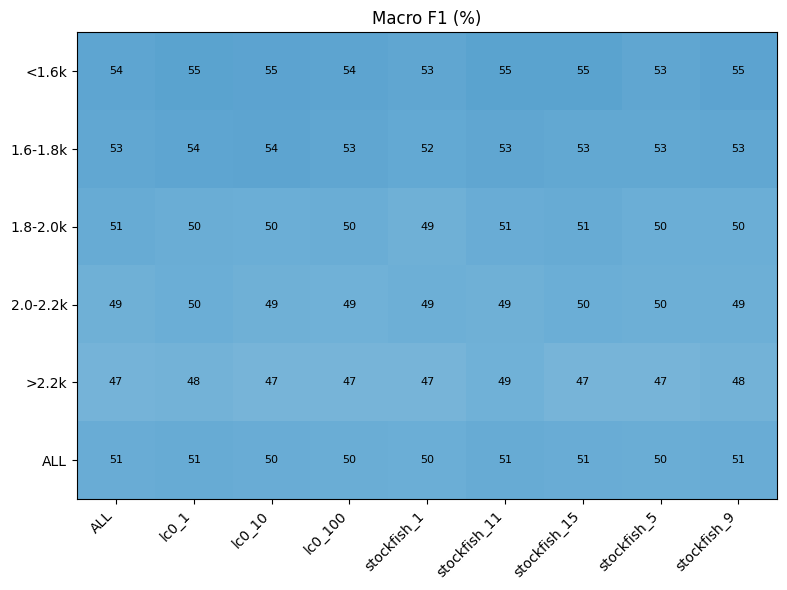

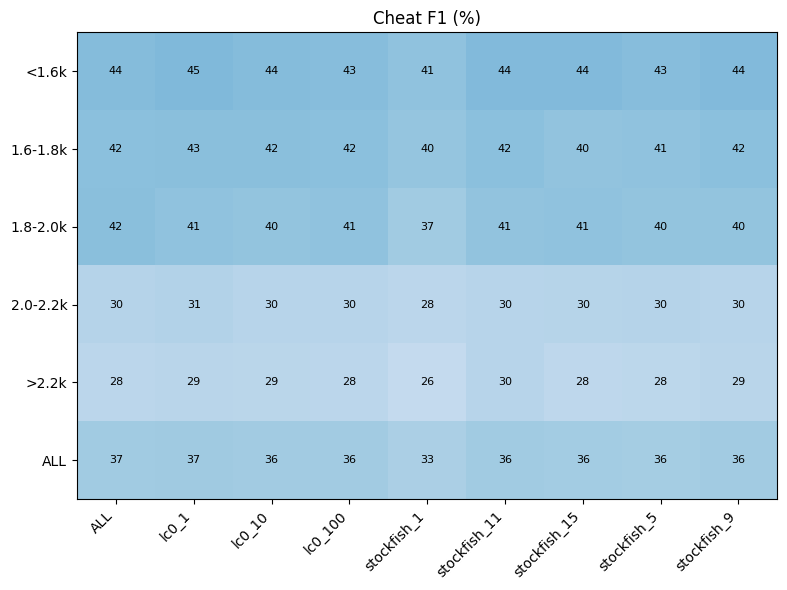

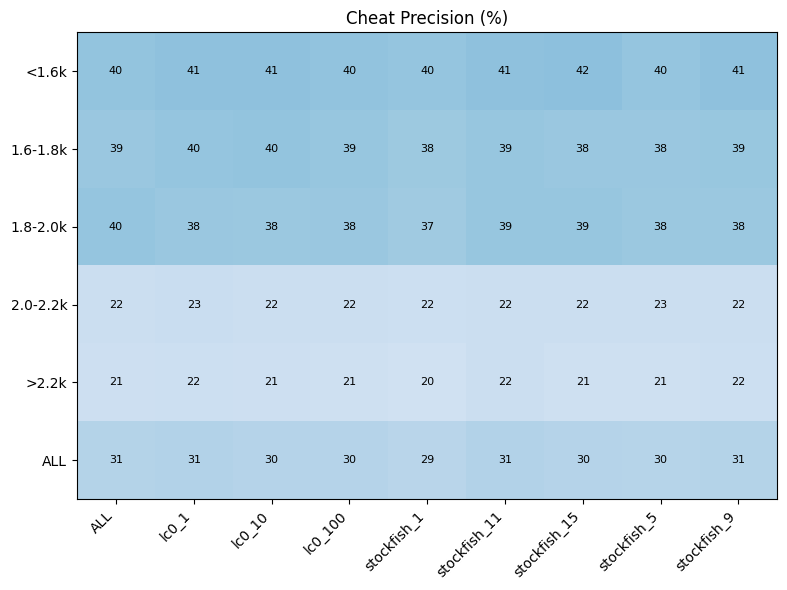

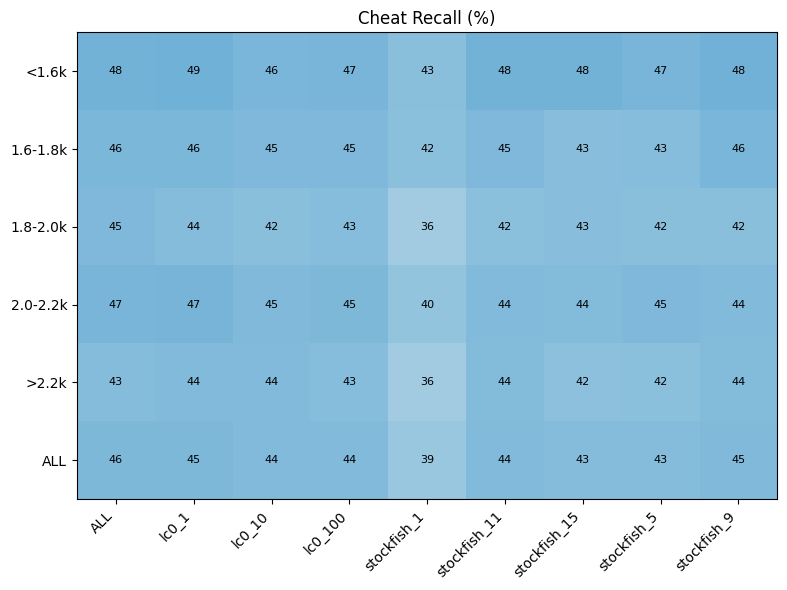

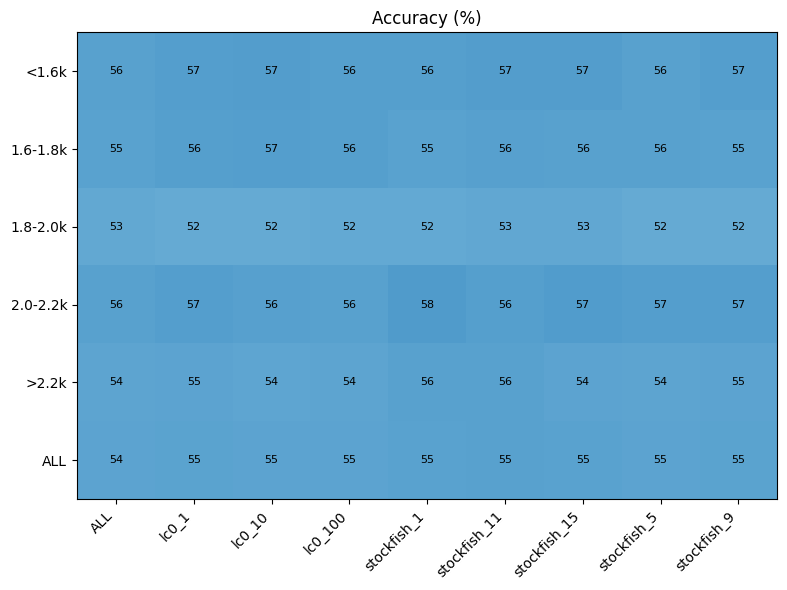

In [11]:
# === Heatmaps (same style as training notebook) ===
import matplotlib.pyplot as plt

def plot_metric_heatmap(
    tbl: pd.DataFrame,
    *,
    title: str,
    out_path: Path,
    vmin: float = 0.0,
    vmax: float = 1.0,
    figsize: tuple[int, int] = (10, 6),
    show_values: bool = True,
) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    mat = tbl.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    _im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="Blues", interpolation="nearest")

    ax.set_xticks(range(tbl.shape[1]))
    ax.set_yticks(range(tbl.shape[0]))
    ax.set_xticklabels([str(c) for c in tbl.columns], rotation=45, ha="right")
    ax.set_yticklabels([str(r) for r in tbl.index])
    ax.set_title(title)

    if show_values:
        for i in range(tbl.shape[0]):
            for j in range(tbl.shape[1]):
                v = mat[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v*100:.0f}", ha="center", va="center", fontsize=8, color="black")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

TRASH_DIR = OUT_DIR / "tables" / "trash"
TRASH_DIR.mkdir(parents=True, exist_ok=True)

for m, title in [
    ("macro_f1", "Macro F1 (%)"),
    ("cheat_f1", "Cheat F1 (%)"),
    ("cheat_precision", "Cheat Precision (%)"),
    ("cheat_recall", "Cheat Recall (%)"),
    ("accuracy", "Accuracy (%)"),
]:
    plot_metric_heatmap(
        tables[m],
        title=title,
        out_path=TRASH_DIR / f"heatmap__{m}.png",
        figsize=(max(10, 0.6 * len(tables[m].columns)), max(6, 0.45 * len(tables[m].index))),
    )
